# 1. Segmentação e Isolamento do Objeto
Este notebook carrega a imagem original em RGB e compara dois métodos de segmentação: Limiarização Global (Otsu) e Espaço de Cor (HSV), isolando a fruta do fundo.

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_image(filepath):
    img = cv2.imread(filepath)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def segment_otsu(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    return mask, result

def segment_hsv(img_rgb):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lower_red1 = np.array([0, 40, 40])
    upper_red1 = np.array([20, 255, 255])
    lower_red2 = np.array([160, 40, 40])
    upper_red2 = np.array([180, 255, 255])
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 | mask2
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    return mask, result

## Visualização e Comparação
Execução dos métodos e plotagem comparativa para análise no relatório técnico.

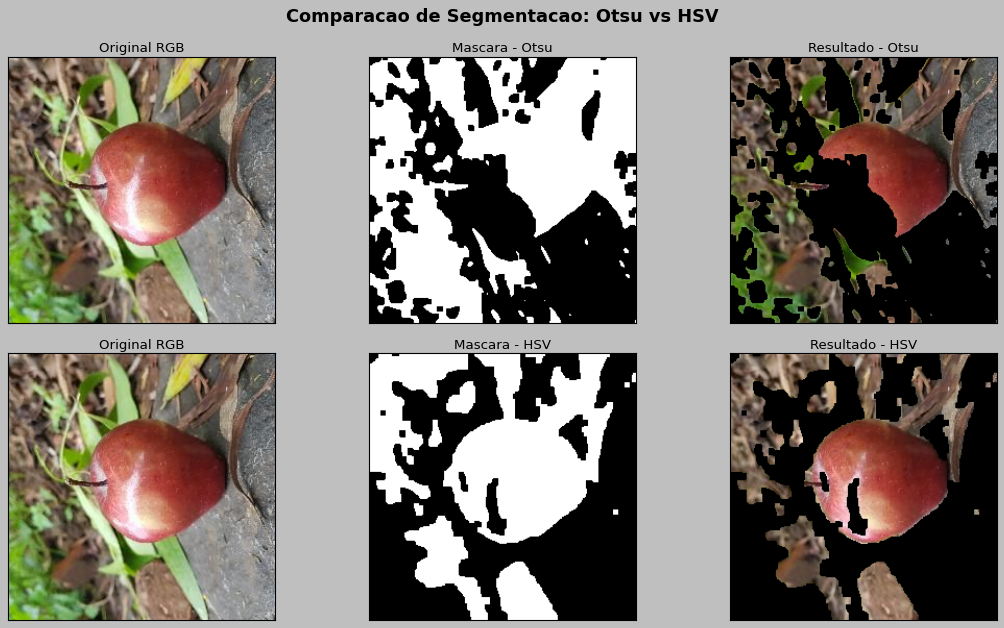

In [22]:
def plot_comparison(img_rgb, mask_otsu, res_otsu, mask_hsv, res_hsv):
    fig, axs = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle('Comparacao de Segmentacao: Otsu vs HSV', fontsize=16, fontweight='bold')

    # Linha 1: Abordagem Clássica (Otsu)
    axs[0, 0].imshow(img_rgb)
    axs[0, 0].set_title('Original RGB', fontsize=12)
    
    axs[0, 1].imshow(mask_otsu, cmap='gray')
    axs[0, 1].set_title('Mascara - Otsu', fontsize=12)
    
    axs[0, 2].imshow(res_otsu)
    axs[0, 2].set_title('Resultado - Otsu', fontsize=12)

    # Linha 2: Abordagem Cromática (HSV)
    axs[1, 0].imshow(img_rgb)
    axs[1, 0].set_title('Original RGB', fontsize=12)
    
    axs[1, 1].imshow(mask_hsv, cmap='gray')
    axs[1, 1].set_title('Mascara - HSV', fontsize=12)
    
    axs[1, 2].imshow(res_hsv)
    axs[1, 2].set_title('Resultado - HSV', fontsize=12)

    # Remove as bordas e numerações dos eixos (X/Y) de forma limpa, mantendo os títulos
    for ax in axs.flat:
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.tight_layout()
    plt.show()

caminho_teste = "/home/akdag/Desktop/vis_computacional/dataset/good_quality_fruits/Apple_Good/20190809_161729.jpg"
img = load_image(caminho_teste)

if img is not None:
    m_otsu, r_otsu = segment_otsu(img)
    m_hsv, r_hsv = segment_hsv(img)
    plot_comparison(img, m_otsu, r_otsu, m_hsv, r_hsv)